# Student GPA Multiple Linear Regression

## Overview

This notebook demonstrates how to build a Multiple Linear Regression model using scikit-learn to predict student GPA using multiple independent variables.

The analysis covers:

- Loading and exploring the dataset
- Training a multiple regression model
- Evaluating model performance
- Interpreting regression coefficients
- Predicting GPA
- Visualizing model results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")

Path("figures").mkdir(exist_ok=True)

In [2]:
students = pd.read_csv("student_gpa_multiple_regression.csv")

students.head()

,SAT,"Rand 1,2,3",GPA
0,1714,1,2.40
1,1664,3,2.52
2,1760,3,2.54
3,1685,3,2.74
4,1693,2,2.83


In [3]:
students.info()

students.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SAT         84 non-null     int64  
 1   Rand 1,2,3  84 non-null     int64  
 2   GPA         84 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 2.1 KB


,SAT,"Rand 1,2,3",GPA
count,84.000000,84.000000,84.000000
mean,1845.273810,2.059524,3.330238
std,104.530661,0.855192,0.271617
min,1634.000000,1.000000,2.400000
25%,1772.000000,1.000000,3.190000
50%,1846.000000,2.000000,3.380000
75%,1934.000000,3.000000,3.502500
max,2050.000000,3.000000,3.810000


## Exploratory Data Analysis

Before training the model, let's explore the relationships between the available variables.

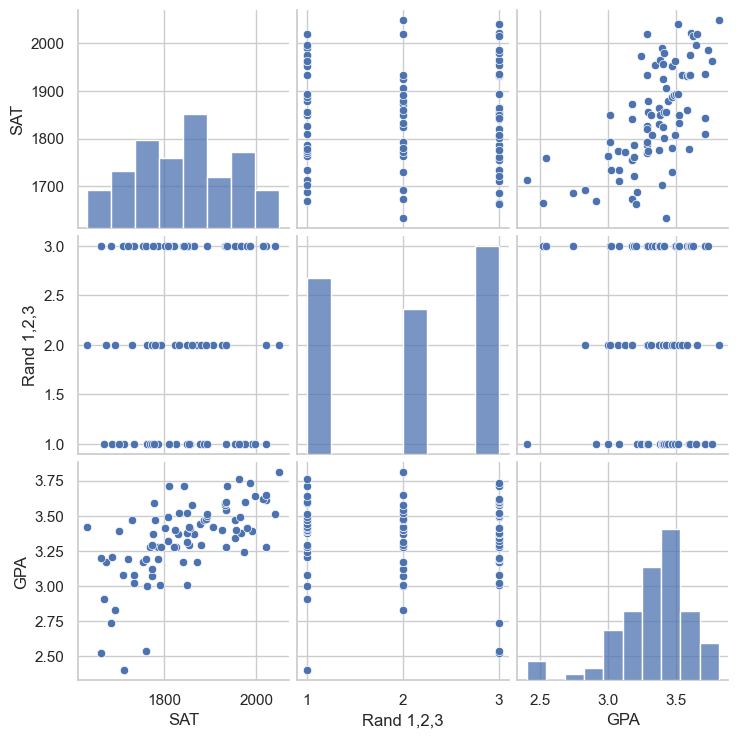

In [5]:
sns.pairplot(students)

plt.show()

In [6]:
X = students[["SAT", "Rand 1,2,3"]]

y = students["GPA"]

model = LinearRegression()

model.fit(X, y)

print("Model trained successfully.")

Model trained successfully.


In [7]:
print(f"Intercept: {model.intercept_:.3f}")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

display(coefficients)

print(f"\nR² Score: {model.score(X, y):.3f}")

Intercept: 0.296


,Feature,Coefficient
0,SAT,0.001654
1,"Rand 1,2,3",-0.008270



R² Score: 0.407


In [8]:
students["Predicted GPA"] = model.predict(X)

students[
    [
        "SAT",
        "Rand 1,2,3",
        "GPA",
        "Predicted GPA"
    ]
].head()

,SAT,"Rand 1,2,3",GPA,Predicted GPA
0,1714,1,2.40,3.121933
1,1664,3,2.52,3.022717
2,1760,3,2.54,3.181457
3,1685,3,2.74,3.057441
4,1693,2,2.83,3.078939


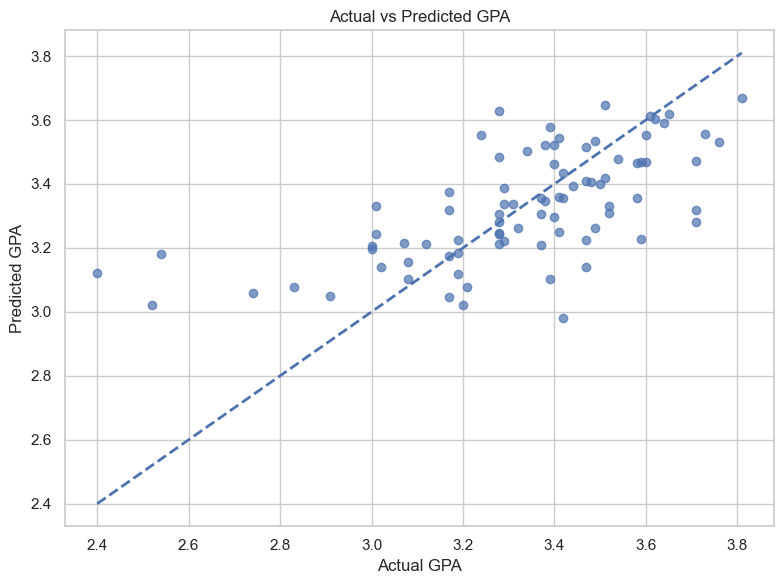

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    students["GPA"],
    students["Predicted GPA"],
    alpha=0.7
)

plt.plot(
    [students["GPA"].min(), students["GPA"].max()],
    [students["GPA"].min(), students["GPA"].max()],
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted GPA")

plt.xlabel("Actual GPA")

plt.ylabel("Predicted GPA")

plt.tight_layout()

plt.savefig(
    "figures/actual_vs_predicted_gpa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
summary = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

summary.loc[len(summary)] = [
    "Intercept",
    model.intercept_
]

summary

,Feature,Coefficient
0,SAT,0.001654
1,"Rand 1,2,3",-0.008270
2,Intercept,0.296033


# Conclusions

This notebook demonstrates how Multiple Linear Regression extends Simple Linear Regression by using multiple independent variables to improve predictions.

Key concepts demonstrated include:

- Training a supervised machine learning model
- Using multiple features to predict a target variable
- Interpreting regression coefficients
- Evaluating model performance using R²
- Comparing predicted values to actual observations

Multiple Linear Regression is widely used in business analytics, finance, operations, healthcare, and forecasting to model relationships between several predictors and a single outcome.